# 11-Vision Transformers (ViT)

From 2012 to 2020, the Convolutional Neural Network (CNN) held an absolute monopoly over Computer Vision. If you were analyzing an image, you used a sliding window (Kernel) to extract local features.

But Convolutions have a fatal geometric flaw: **They are inherently local.** A $3 \times 3$ kernel can only see 9 pixels at a time. To understand the global context of an image (e.g., "The astronaut's helmet on the top implies the space suit is on the bottom"), a CNN must aggressively pool the image down through dozens of layers until the Receptive Field is large enough to encompass both.

In 2020, Google Brain published a paper titled: *"An Image is Worth 16x16 Words."* They completely abandoned the Convolution. Instead, they took the architecture that revolutionized Natural Language Processing (the **Transformer**) and applied it natively to images.

Let's set up our PyTorch environment to map the architecture of the future.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Vision Transformer Environment Ready.")


✅ PyTorch Vision Transformer Environment Ready.


# 1. The Image as a Sentence (Patch Extraction)

A standard Transformer (like the one powering ChatGPT) is mathematically designed to process a 1D sequence of text tokens (words). An image, however, is a 3D spatial grid. How do we feed a physical grid into a sequence engine?

We physically chop the image into a grid of non-overlapping squares called **Patches**.

If we have a standard $224 \times 224$ RGB image, and we choose a patch size of $P = 16$:

1. We slice the image into a $14 \times 14$ grid ($\frac{224}{16} = 14$).
2. This yields exactly $196$ patches.
3. Each individual patch is a small physical image of size $16 \times 16 \times 3$.

### The Linear Projection (Flattening)

The Transformer doesn't want a 2D patch; it wants a 1D mathematical vector (exactly like a word embedding). We mathematically flatten each $16 \times 16 \times 3$ patch ($768$ numbers) into a single 1D vector of size $768$.

**The Paradigm Shift**: The network no longer sees an "image". It sees a "sentence" containing 196 "words".

# 2. Positional Embeddings (Injecting Space)

There is a catastrophic problem with chopping an image into a sentence of patches. **Transformers have no concept of order, geometry, or 2D space.** If you feed 196 patches into a Transformer, it treats them as a scrambled bag of puzzle pieces. It doesn't know that Patch 1 is in the top-left corner and Patch 196 is in the bottom-right. If you physically shuffled the patches before feeding them in, the Transformer would output the exact same mathematical result.

To fix this, we use **Positional Embeddings**.
We create a highly specific, learnable 1D vector for every single physical position in the $14 \times 14$ grid. Before the patches enter the Transformer, we mathematically *add* the Positional Embedding vector directly to the Patch vector.

$$z_0 = [x_{class}; x_p^1 E; x_p^2 E; \dots; x_p^N E] + E_{pos}$$


*(Where $x_p$ are the patches, $E$ is the linear projection matrix, and $E_{pos}$ is the positional embedding).*

Because the network lacks the Inductive Bias of a sliding convolution, we have artificially injected the geometry of space directly into the numbers.

# 3. Multi-Head Self-Attention (The Global View)

Once the sequence of patches enters the Transformer Encoder, we replace the local sliding Convolution operation with **Global Self-Attention**.

Instead of a kernel sliding over neighboring pixels, Self-Attention allows **every single patch to mathematically look at every other patch in the image simultaneously, in a single forward pass.**

* Patch 42 (the astronaut's visor) mathematically queries all 195 other patches.
* It notices a high mathematical correlation with Patch 112 (the American flag patch on her shoulder) on the opposite side of the image.
* The attention mechanism mathematically links them together instantly at Layer 1.

A CNN would require 50 layers of pooling to connect the visor to the flag. A ViT connects them in exactly 1 layer. This infinite Receptive Field from step zero is what allows ViTs to fundamentally outperform CNNs on massive datasets.

# 4. The Classification Token (`[CLS]`)

If the network processes 196 patches, it will output 196 updated vectors. If we are trying to do Image Classification, which of the 196 vectors do we send to the final Dense layer?

We don't use any of them. ViTs prepend a fake, blank, 197th patch to the sequence called the **Classification Token (`[CLS]`)**.

As this empty `[CLS]` token moves through the self-attention layers, its only job is to look at the other 196 patches and mathematically aggregate the global context of the entire image into itself. At the very end of the network, we throw away the 196 image patches, take the 1 single `[CLS]` token, and feed it into a standard `nn.Linear` layer to get our final prediction.

# 5. Exploring a ViT in PyTorch

Let's load a true Vision Transformer from PyTorch, inspect its geometry, and manually simulate the math of chopping our real `skimage` image into a sequence of patches.

--- 📥 Initializing Vision Transformer (ViT-B_16) ---
Total Parameters: 86,567,656
Insight: ViTs require significantly more parameters and data to train than CNNs because they lack the 'inductive bias' of sliding windows. They have to learn the concept of 2D space from absolute scratch!

--- 🔪 The Mathematics of Patch Extraction ---
Original Image Tensor: torch.Size([1, 3, 224, 224]) [B, C, H, W]
Projected Grid Shape:  torch.Size([1, 768, 14, 14])
Sequence Tensor Shape: torch.Size([1, 196, 768])
Insight: The tensor is now [1 Batch, 196 Tokens, 768 Dimensions]. It is mathematically identical to a sentence containing 196 words!


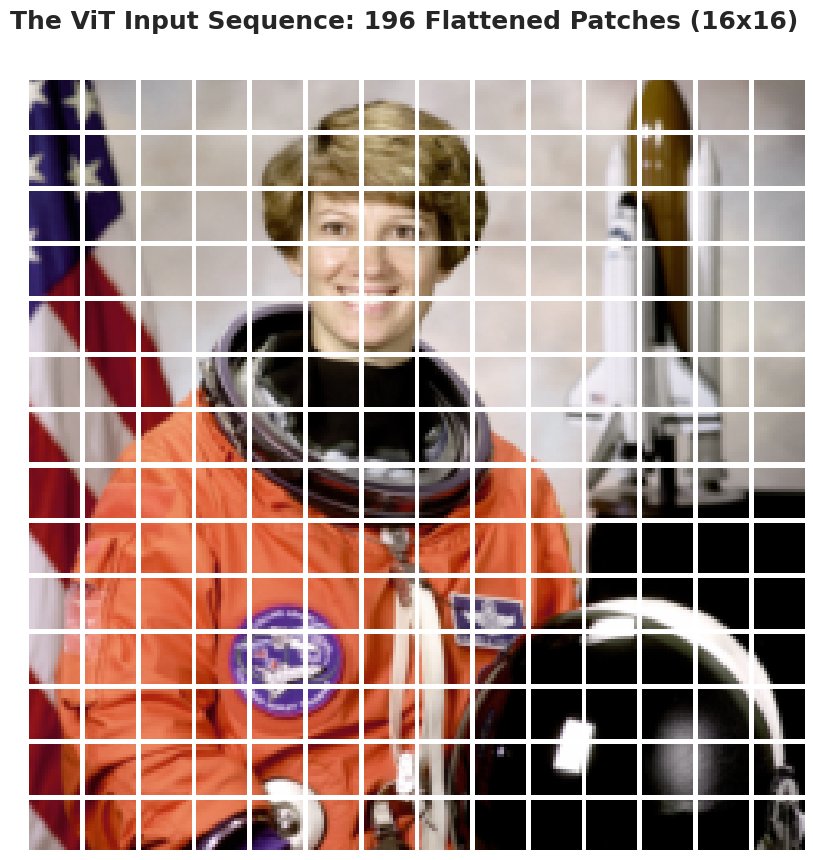


--- 🧠 Full Network Execution ---
Final Output Shape:    torch.Size([1, 1000]) (1,000 ImageNet Classes)
Prediction:            bobsled (Confidence: 32.41%)


In [2]:
# 1. Fetch and Preprocess the Target Image
numpy_img = data.astronaut()

# ViTs strictly require 224x224 input geometry
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_tensor = transform(numpy_img).unsqueeze(0)

# 2. Load an Enterprise Vision Transformer (ViT-Base 16)
print("--- 📥 Initializing Vision Transformer (ViT-B_16) ---")
weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit = models.vit_b_16(weights=weights)
vit.eval()

# Count the parameters (ViTs are massively heavy!)
vit_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"Total Parameters: {vit_params:,.0f}")
print("Insight: ViTs require significantly more parameters and data to train than CNNs because they lack the 'inductive bias' of sliding windows. They have to learn the concept of 2D space from absolute scratch!\n")

# 3. The Mathematics of Patch Extraction
print("--- 🔪 The Mathematics of Patch Extraction ---")
print(f"Original Image Tensor: {img_tensor.shape} [B, C, H, W]")

# In PyTorch, the 'Linear Projection' of patches is ingeniously executed
# using a Conv2d layer with a kernel size AND stride perfectly equal to the patch size!
# This physically chops the image into non-overlapping grids.
patch_projector = vit.conv_proj 

# Output shape: [Batch, Hidden_Dim, Grid_H, Grid_W] -> [1, 768, 14, 14]
patched_grid = patch_projector(img_tensor)
print(f"Projected Grid Shape:  {patched_grid.shape}")

# 4. Flattening into a 1D Sequence
# We must destroy the 14x14 2D grid and unroll it into 196 sequential tokens
# We flatten dimensions 2 and 3 (the 14x14), resulting in [1, 768, 196]
sequence = patched_grid.flatten(2)

# Transformers expect the sequence length first: [Batch, Tokens, Hidden_Dim]
sequence = sequence.transpose(1, 2)

print(f"Sequence Tensor Shape: {sequence.shape}")
print("Insight: The tensor is now [1 Batch, 196 Tokens, 768 Dimensions]. It is mathematically identical to a sentence containing 196 words!")

# 5. Visualizing the "Image as a Sentence" Concept
# We will physically chop the raw image array into 16x16 patches to see what the network sees
img_resized = transforms.Resize((224, 224))(transforms.ToPILImage()(numpy_img))
img_array = np.array(img_resized)

# Setup a grid to visualize the sequence
fig, axes = plt.subplots(14, 14, figsize=(10, 10))
fig.suptitle("The ViT Input Sequence: 196 Flattened Patches (16x16)", fontsize=18, fontweight='bold', y=0.95)

# Iterate through the grid and extract each 16x16 pixel block
for i in range(14):
    for j in range(14):
        # Extract the patch
        patch = img_array[i*16:(i+1)*16, j*16:(j+1)*16, :]
        axes[i, j].imshow(patch)
        axes[i, j].axis('off')

# Add spacing to emphasize that these are disconnected "tokens", not a continuous image
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

# 6. The [CLS] Token and Final Forward Pass
print("\n--- 🧠 Full Network Execution ---")
# To prove it works, we pass the original image through the entire network
with torch.no_grad():
    logits = vit(img_tensor)
    
# Extract top prediction
probs = torch.nn.functional.softmax(logits, dim=1)[0]
top_prob, top_class = torch.max(probs, 0)
class_name = weights.meta["categories"][top_class.item()]

print(f"Final Output Shape:    {logits.shape} (1,000 ImageNet Classes)")
print(f"Prediction:            {class_name} (Confidence: {top_prob.item()*100:.2f}%)")

## Real-World Use Case or Analogy:

Think of the difference between a CNN and a ViT like **Two different strategies for analyzing a giant, complex mural**:

* **The CNN (The Inspector with a Magnifying Glass)**: You trace your magnifying glass slowly over every inch of the mural, bottom to top. You find a patch of orange fabric. You slide up, find a zipper, slide up, find a helmet. By tracing the continuous, physical lines connected to each other, you eventually conclude you are looking at an astronaut. You rely heavily on physical proximity (local sliding window).
* **The ViT (The Puzzle Master)**: You take a sledgehammer and violently smash the mural into 196 perfectly square tiles (Patch Extraction). You throw all 196 tiles onto a table. You pick up a tile containing a shiny helmet visor. Instead of looking at the tiles physically next to it, you instantly cross-reference that visor with *every single other tile on the table at the exact same time* (Self-Attention). You immediately find the American flag tile on the other side of the table, mathematically link them together, and solve the context of the image instantly without having to trace the physical path between them.